# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

In [9]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Realize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [10]:
# Verificando os tipos de dados das colunas
df.dtypes

,0
Age,float64
Gender,object
Income,object
Education,object
Marital Status,object
Number of Children,int64
Home Ownership,object
Credit Score,object


In [11]:
# Transformando a variável Income para tipo float, pois trata-se de salários anuais e está com o tipo object
df['Income'] = df['Income'].str.replace('.', '', regex=False)
df['Income'] = df['Income'].str.replace(',', '.', regex=False)
df['Income'] = df['Income'].astype(float)
df.dtypes

,0
Age,float64
Gender,object
Income,float64
Education,object
Marital Status,object
Number of Children,int64
Home Ownership,object
Credit Score,object


**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [12]:
# Verificando quantidade de valores faltantes por coluna
df.isnull().sum()

,0
Age,34
Gender,0
Income,0
Education,0
Marital Status,0
Number of Children,0
Home Ownership,0
Credit Score,0


In [13]:
# Apenas a variável de idade possui dados faltantes, por isso os valores faltantes serão substituídos pela média dos valores, para manter a distribuição geral e evita redução da base de dados

df['Age'] = df['Age'].fillna(df['Age'].mean())
df.isnull().sum()

,0
Age,0
Gender,0
Income,0
Education,0
Marital Status,0
Number of Children,0
Home Ownership,0
Credit Score,0


**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [14]:
# Verificando valores únicos das variáveis categóricas
print("Gender:", df['Gender'].unique())
print("Education:", df['Education'].unique())
print("Marital Status:", df['Marital Status'].unique())
print("Home Ownership:", df['Home Ownership'].unique())
print("Credit Score:", df['Credit Score'].unique())

Gender: ['Female' 'Male']
Education: ["Bachelor's Degree" "Master's Degree" 'Doctorate' 'High School Diploma'
 "Associate's Degree"]
Marital Status: ['Single' 'Married']
Home Ownership: ['Rented' 'Owned']
Credit Score: ['High' 'Average' 'Low']


# Etapa 2: Realize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

In [16]:
# Estatísticas descritivas das variáveis numéricas

df.describe()

,Age,Income,Number of Children
count,164.000000,164.000000,164.000000
mean,37.507692,83765.243902,0.652439
std,7.561808,32457.306728,0.883346
min,25.000000,25000.000000,0.000000
25%,31.750000,57500.000000,0.000000
50%,37.507692,83750.000000,0.000000
75%,43.000000,105000.000000,1.000000
max,53.000000,162500.000000,3.000000


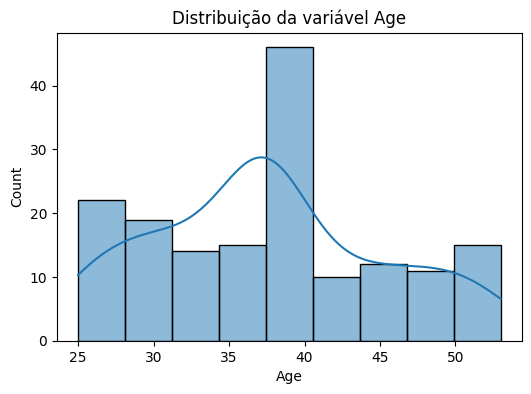

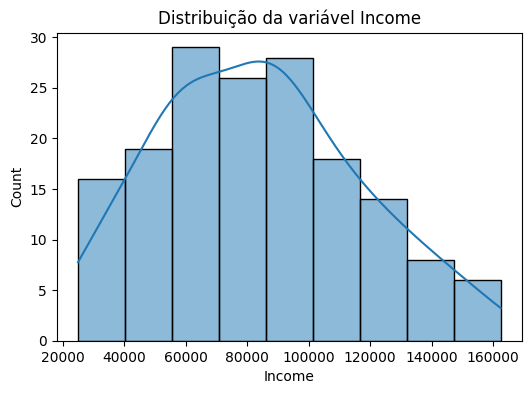

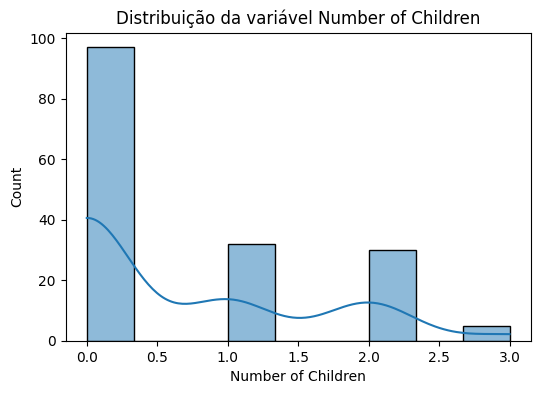

In [17]:
# Selecionando variáveis numéricas
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

# Histogramas para visualizar distribuição
for col in numerical_cols:

    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição da variável {col}')
    plt.show()

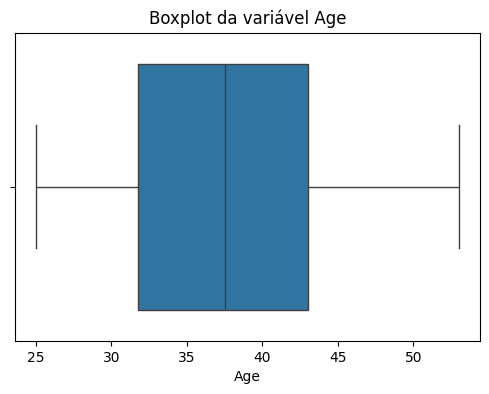

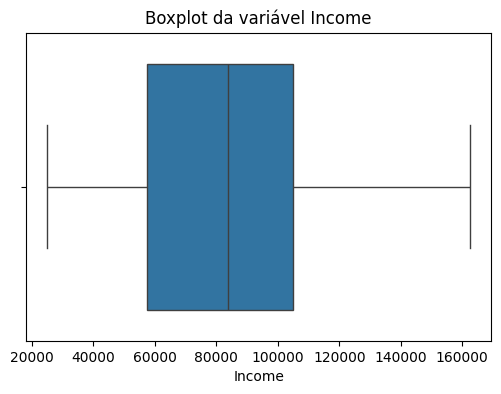

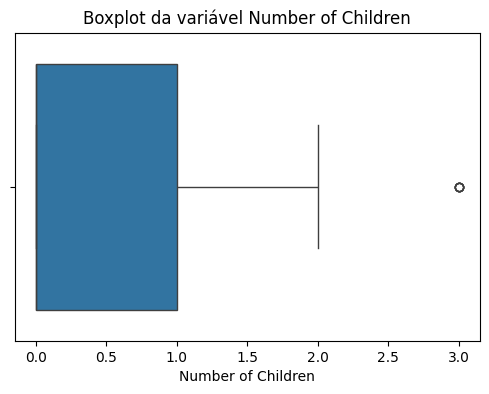

In [18]:
# Boxplot para identificar outliers

for col in numerical_cols:

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot da variável {col}')
    plt.show()

A variável Income sugere alguns outliers de renda, com valores muito acima da média

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

In [19]:
# Selecionando variáveis categóricas
categorical_cols = df.select_dtypes(include='object').columns

categorical_cols

Index(['Gender', 'Education', 'Marital Status', 'Home Ownership',
       'Credit Score'],
      dtype='object')

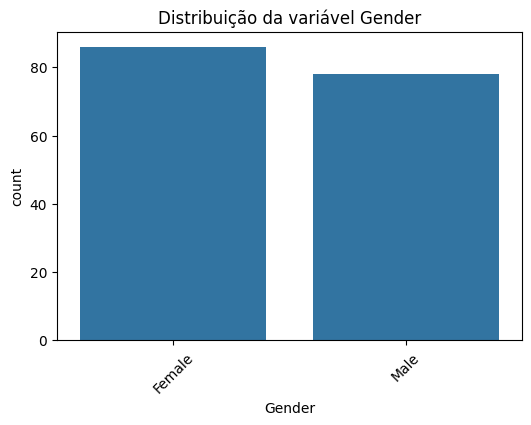

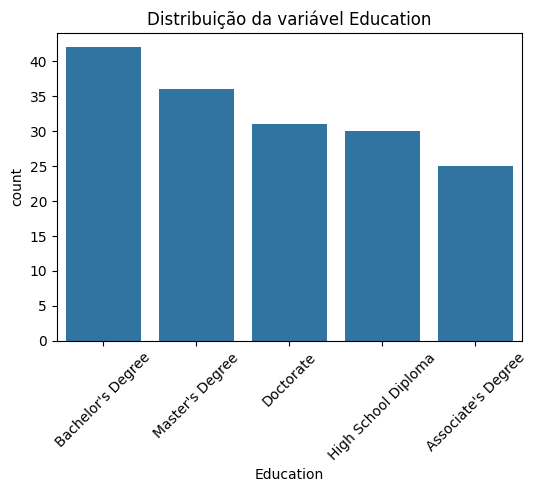

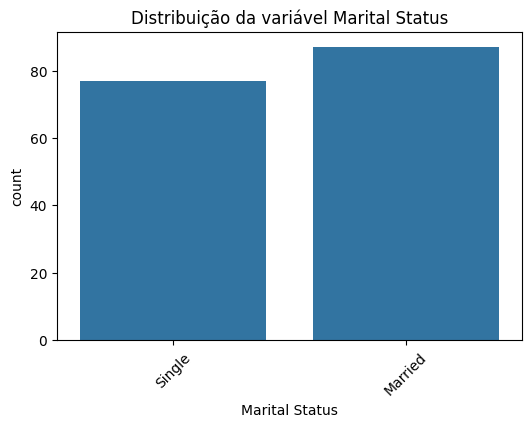

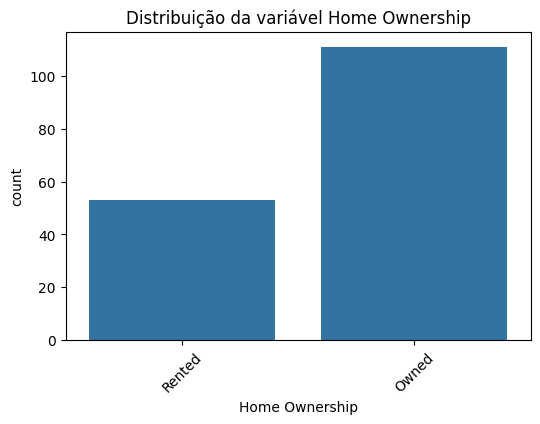

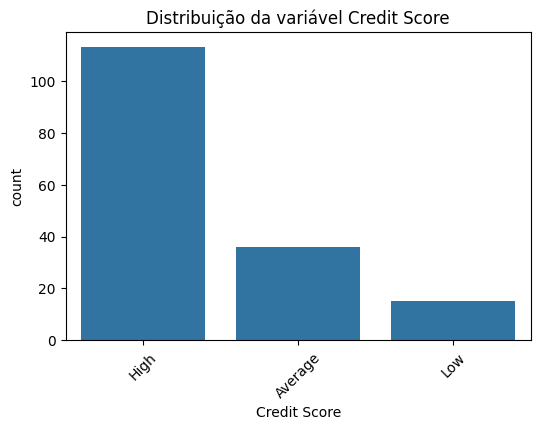

In [20]:
# Gráfico de contagem para cada variável categórica

for col in categorical_cols:

    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribuição da variável {col}')
    plt.xticks(rotation=45)
    plt.show()

Insights para as variáveis:

**Gender**: Permite observar que existe equilíbrio entre homens e mulheres na base, porém com um sutil aumento no número de mulheres;
**Education**: Podemos verificar que o bacharel é o nível educacional é mais comum entre os clientes;
**Marital Status**: Permite entender que a maioria dos clientes está equilibrada entre casada e solteira, possuindo mais casados;
**Home Ownership:** Identifica proporção de clientes com casa própria ou aluguel, tendo uma relevante quantidade com casa própria;
**Credit Score:** Permite entender a distribuição entre Low, Average e High.Possui mais clientes com score de crédito alto.

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

A variável Income, por isso foi realizado o tratamento de outliers pois poderíam distorcer análises, prejudicar modelos de machine learning e criar falsas correlações

In [21]:
# Calculando limites usando IQR para a variável Income

Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(limite_inferior, limite_superior)

-13750.0 176250.0


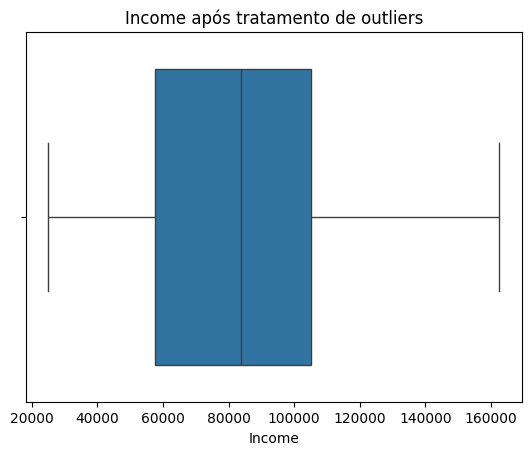

In [22]:
# Removendo registros com outliers

df = df[(df['Income'] >= limite_inferior) & (df['Income'] <= limite_superior)]

# Verificando nova distribuição
sns.boxplot(x=df['Income'])
plt.title("Income após tratamento de outliers")
plt.show()

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



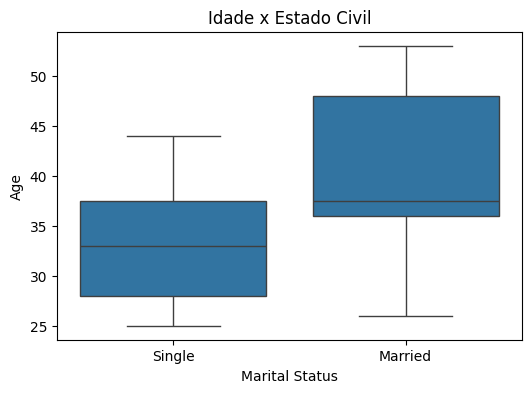

In [24]:
# Existe relação entre a idade e o status civil? Clientes casados costumam ser mais velhos e solteiros mais jovens

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Marital Status', y='Age')
plt.title("Idade x Estado Civil")
plt.show()

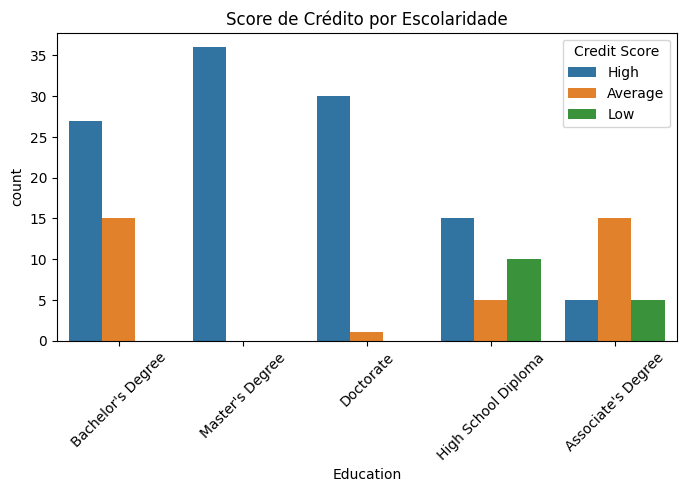

In [26]:
# Qual a relação entre o score de crédito e o nível de escolaridade? Níveis superiores de ensino tendem a um score de crédito maior
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Education', hue='Credit Score')
plt.xticks(rotation=45)
plt.title("Score de Crédito por Escolaridade")
plt.show()

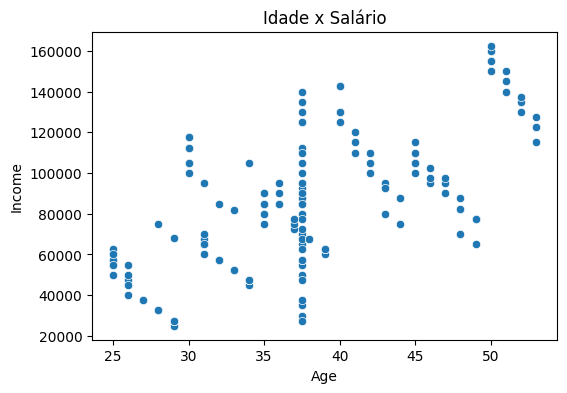

In [30]:
# O salário parece influenciar na idade? Existe uma tendência natural de que o aumento de idade pode trazer salários maiores, mas principalmente em idades médias
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Age', y='Income')
plt.title("Idade x Salário")
plt.show()

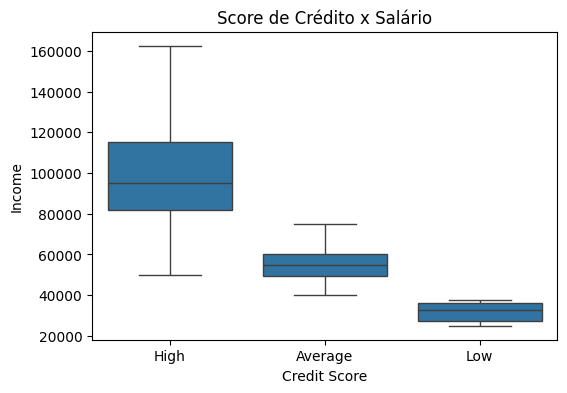

In [29]:
# O salário parece influenciar no Score de Crédito? Sim, pessoas com média de salários mais altos tendem a ter scores mais altos
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Credit Score', y='Income')
plt.title("Score de Crédito x Salário")
plt.show()

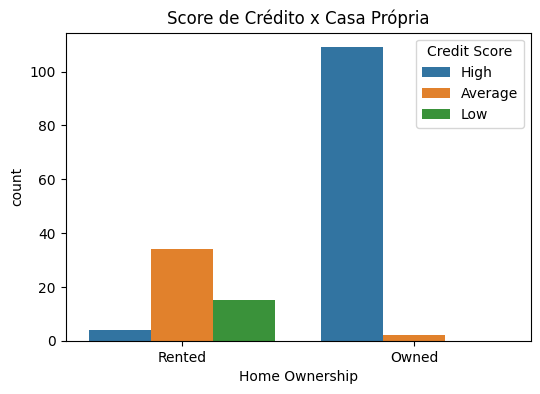

In [32]:
# Clientes com casa própria tendem a ter um score mais alto?  Sim, a partir dos gráficos pessoas que alugam costumam ter scores médio ou baixo, enquanto pessoas com casa própria costumam ter score alto

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Home Ownership', hue='Credit Score')
plt.title("Score de Crédito x Casa Própria")
plt.show()

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

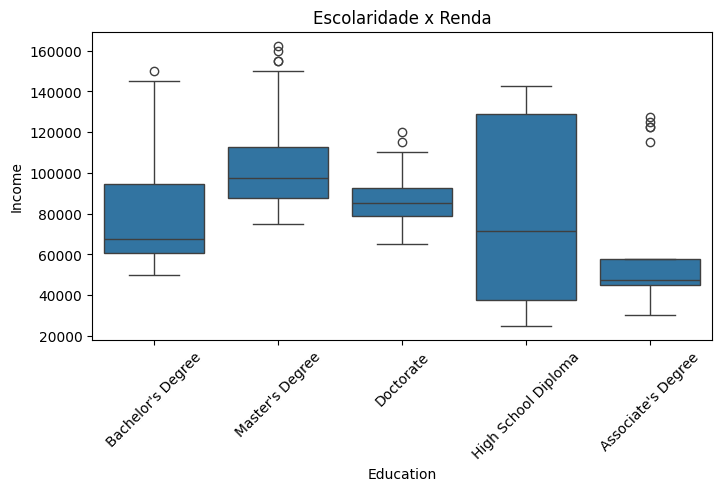

In [34]:
# Pessoas com maior escolaridade possuem renda maior? Pode indicar que a média de salário anual aumente conforme nível educacional aumenta

plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Education', y='Income')
plt.xticks(rotation=45)
plt.title("Escolaridade x Renda")
plt.show()

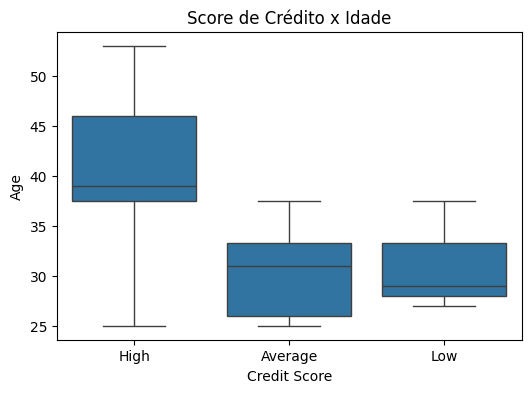

In [36]:
# Existe relação entre idade e score de crédito? Sim, a medida que a idade aumenta, principalmente após os 35, o score de crédito começa a aumentar.
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Credit Score', y='Age')
plt.title("Score de Crédito x Idade")
plt.show()

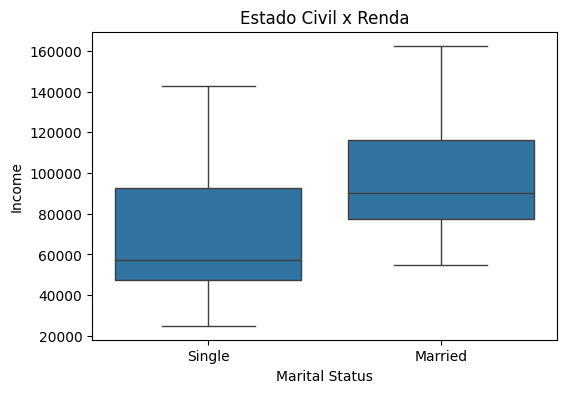

In [38]:
# Estado civil influencia renda? Pessoas casadas costumam possuir uma renda média anual maior
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Marital Status', y='Income')
plt.title("Estado Civil x Renda")
plt.show()

# Etapa 3: Realize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

In [39]:
# Selecionando apenas variáveis numéricas
numerical_df = df.select_dtypes(include=['int64','float64'])

# Matriz de correlação
corr_matrix = numerical_df.corr()

# Exibindo tabela de correlação
corr_matrix

,Age,Income,Number of Children
Age,1.000000,0.620968,0.071032
Income,0.620968,1.000000,0.084547
Number of Children,0.071032,0.084547,1.000000


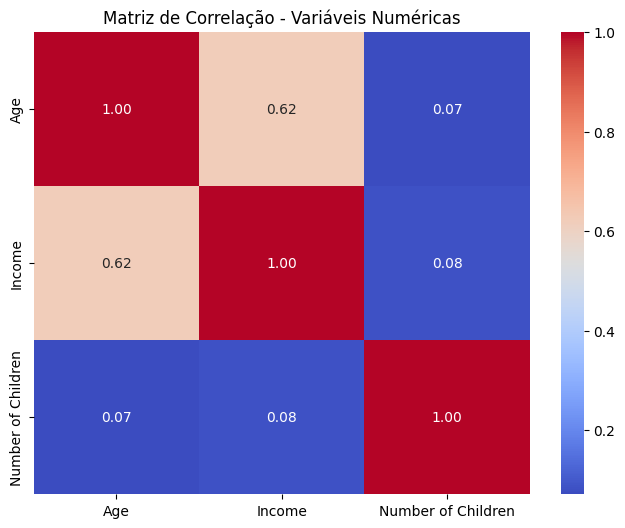

In [40]:
# Plotando matriz de correlação

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Matriz de Correlação - Variáveis Numéricas")
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

Com base na correlação entre as variáveis Age, Income e Number of Children: Age e Income apresentam correlação positiva moderada, pois pessoas mais velhas tendem a ter maior estabilidade financeira. Income e Number of Children apresentam correlação baixa, já que número de filhos não necessariamente depende da renda. Age e Number of Children tem correlação moderada, pois pessoas mais velhas tendem a ter mais filhos.

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [41]:
# Separando variável alvo
target = df['Credit Score']

# Separando as variáveis preditoras
X = df.drop('Credit Score', axis=1)

# Aplicando One Hot Encoding nas variáveis categóricas
X_encoded = pd.get_dummies(X, drop_first=True)

# Visualizando novas colunas
X_encoded.head()

,Age,Income,Number of Children,Gender_Male,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital Status_Single,Home Ownership_Rented
0,25.0,50000.0,0,False,True,False,False,False,True,True
1,30.0,100000.0,2,True,False,False,False,True,False,False
2,35.0,75000.0,1,False,False,True,False,False,False,False
3,40.0,125000.0,0,True,False,False,True,False,True,False
4,45.0,100000.0,3,False,True,False,False,False,False,False


In [42]:
# Recriando dataframe final

df_model = pd.concat([X_encoded, target], axis=1)

df_model.head()

,Age,Income,Number of Children,Gender_Male,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital Status_Single,Home Ownership_Rented,Credit Score
0,25.0,50000.0,0,False,True,False,False,False,True,True,High
1,30.0,100000.0,2,True,False,False,False,True,False,False,High
2,35.0,75000.0,1,False,False,True,False,False,False,False,High
3,40.0,125000.0,0,True,False,False,True,False,True,False,High
4,45.0,100000.0,3,False,True,False,False,False,False,False,High


**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

In [43]:
# Convertendo target para numérico usando Label Encoder

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_model['Credit Score'] = le.fit_transform(df_model['Credit Score'])

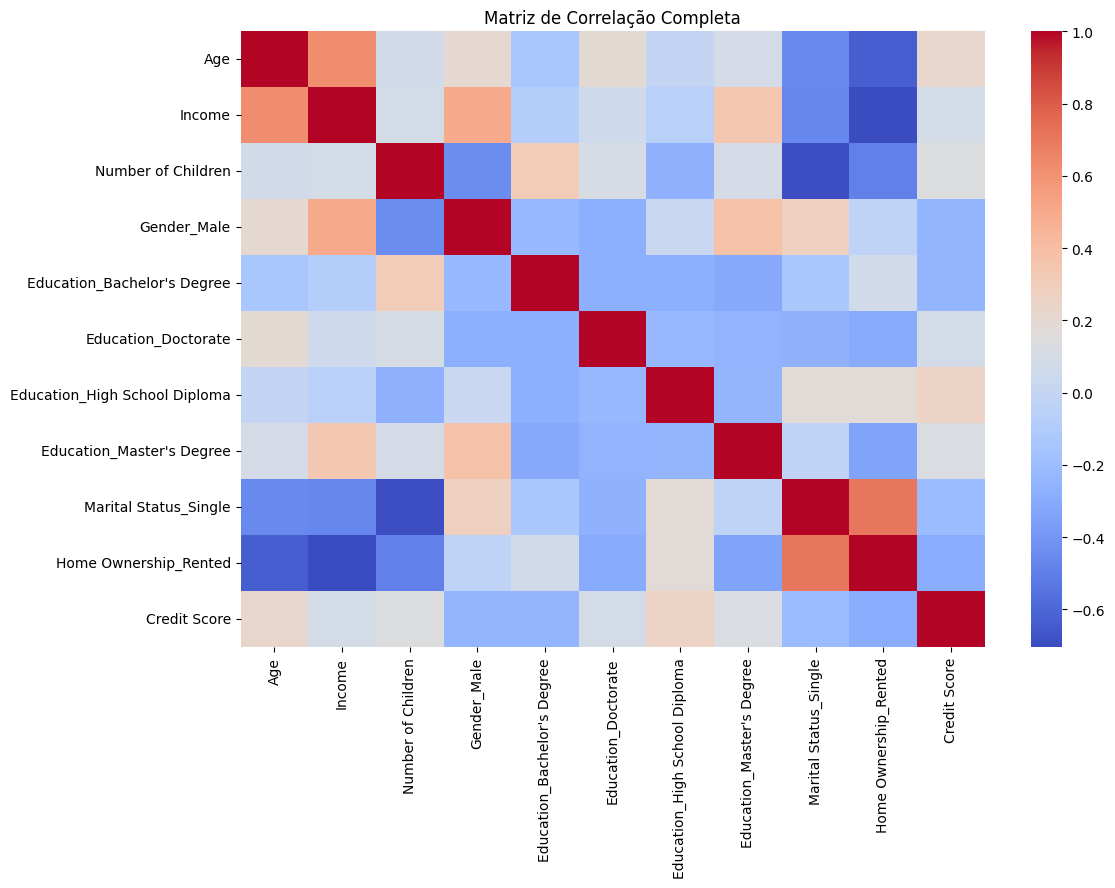

In [44]:
# Calculando nova matriz de correlação

corr_matrix_full = df_model.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix_full,
    cmap='coolwarm',
    annot=False
)

plt.title("Matriz de Correlação Completa")
plt.show()

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [45]:
from sklearn.model_selection import train_test_split

# Separando X e y

X = df_model.drop('Credit Score', axis=1)
y = df_model['Credit Score']

# Divisão treino/teste

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Verificando dimensões

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (131, 10)
Teste: (33, 10)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

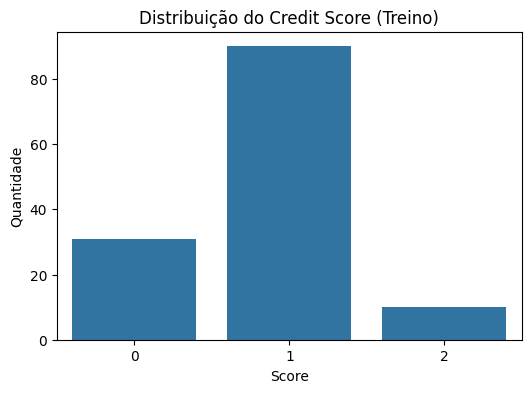

In [46]:
# Distribuição da variável alvo

plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Distribuição do Credit Score (Treino)")
plt.xlabel("Score")
plt.ylabel("Quantidade")

plt.show()

In [47]:
# Percentual das classes

y_train.value_counts(normalize=True)

,proportion
Credit Score,
1,0.687023
0,0.236641
2,0.076336


**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [48]:
from imblearn.over_sampling import SMOTE

# Criando objeto SMOTE

smote = SMOTE(random_state=42)

# Aplicando apenas na base de treino

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Verificando novo balanceamento

print(y_train_bal.value_counts())

Credit Score
1    90
0    90
2    90
Name: count, dtype: int64


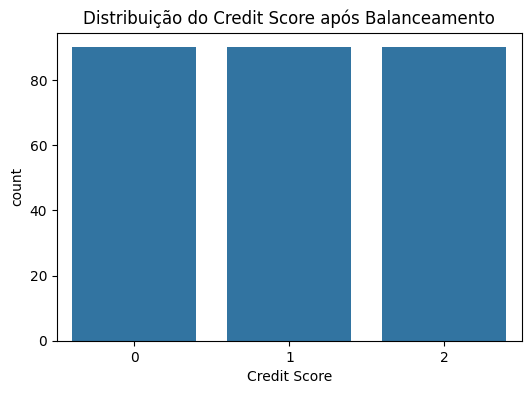

In [49]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train_bal)

plt.title("Distribuição do Credit Score após Balanceamento")

plt.show()